# Locked benchmark ConvexAdam для регистрации вдох–выдох

Этот notebook **не подбирает параметры и не запускает регистрацию**. Он читает сохранённые batch-артефакты:

- конфигурация выбрана на 6 LungCT без expert landmarks;
- locked-конфигурация проверена на 10 DIR-Lab COPDgene и 3 LungCT с независимыми expert landmarks;
- expert landmarks использовались только после построения поля;
- единица анализа — субъект;
- transform: `fixed/expiration → moving/inspiration` в локальной RAS+, мм;
- парные карты формы и толщины разрешаются только после прохождения всех gate-критериев.


**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


locked_paths = {
    "DIR-Lab COPDgene": ARTIFACT_ROOT / "results/registration/convexadam_locked/dirlab/benchmark.csv",
    "Learn2Reg LungCT (expert subset)": ARTIFACT_ROOT
    / "results/registration/convexadam_locked/lungct/benchmark.csv",
}
baseline_paths = {
    "DIR-Lab COPDgene": ARTIFACT_ROOT / "results/registration/dirlab/benchmark.csv",
    "Learn2Reg LungCT (expert subset)": ARTIFACT_ROOT
    / "results/registration/lungct_expert/benchmark.csv",
}
development_paths = {
    "Development results": ARTIFACT_ROOT
    / "results/registration/convexadam_development/development_results.csv",
    "Configuration summary": ARTIFACT_ROOT
    / "results/registration/convexadam_development/configuration_summary.csv",
    "Selection": ARTIFACT_ROOT / "results/registration/convexadam_development/selection.json",
}
required = [*locked_paths.values(), *baseline_paths.values(), *development_paths.values()]
missing = [path.relative_to(ARTIFACT_ROOT).as_posix() for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("Нет требуемых batch-артефактов: " + ", ".join(missing))


def load_cohorts(paths: dict[str, Path]) -> pd.DataFrame:
    frames = []
    for cohort, path in paths.items():
        frame = pd.read_csv(path)
        frame.insert(0, "cohort", cohort)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


locked = load_cohorts(locked_paths)
baseline = load_cohorts(baseline_paths)
locked["gate_pass"] = locked["gate_pass"].astype(bool)
comparison = locked.merge(
    baseline[["dataset_id", "subject_id", "expert_tre_after_mean_mm"]],
    on=["dataset_id", "subject_id"],
    how="inner",
    validate="one_to_one",
    suffixes=("_convexadam", "_elastix"),
)
if len(comparison) != len(locked):
    raise RuntimeError("Locked и baseline таблицы содержат разные expert cases")

print(f"Загружено {len(locked)} locked expert cases и {len(comparison)} matched baseline cases.")
print("DICOM/NIfTI не загружаются; локальные пути к медицинским данным не выводятся.")

Загружено 13 locked expert cases и 13 matched baseline cases.
DICOM/NIfTI не загружаются; локальные пути к медицинским данным не выводятся.


## Выбор конфигурации без expert landmarks

Параметры фиксировались до просмотра expert benchmark. Development-скрипт программно запрещает случаи с expert landmarks и ранжирует конфигурации по image-derived keypoint TRE, FOV-aware Dice/surface p95 и валидности Jacobian в теле/общем FOV.


In [3]:
development_summary = pd.read_csv(development_paths["Configuration summary"])
selection = json.loads(development_paths["Selection"].read_text(encoding="utf-8"))
display(development_summary.round(4))

selected_name = selection.get(
    "selected_configuration", selection.get("selected_name", "smooth7_lambda2")
)
print(f"Зафиксированная конфигурация: {selected_name}")
better_count = (
    comparison["expert_tre_after_mean_mm_convexadam"]
    < comparison["expert_tre_after_mean_mm_elastix"]
).sum()
print(
    "Development subjects: LungCT_0004, 0005, 0008, 0015, 0022, 0029; expert landmarks отсутствуют."
)

,configuration,invalid_cases,mean_multimetric_rank,median_keypoint_tre_mm,median_surface_p95_mm,median_fov_dice,minimum_body_fov_jacobian_p01
0,smooth7_lambda2,0,1.0278,2.6856,6.6746,0.9261,0.4656
1,smooth9_lambda2,0,2.0833,2.8659,6.7340,0.9250,0.5210
2,smooth5_lambda3,2,2.8889,3.2036,7.2950,0.9231,0.4815


Зафиксированная конфигурация: smooth7_lambda2
Development subjects: LungCT_0004, 0005, 0008, 0015, 0022, 0029; expert landmarks отсутствуют.


## Locked-результаты по субъектам

FOV-aware поверхность исключает искусственную границу около края обрезанного тома. Jacobian для gate оценивается внутри `fixed body ∩ common FOV`; global padded-grid метрики сохранены только как legacy QC.


In [4]:
table = locked[
    [
        "cohort",
        "subject_id",
        "expert_count",
        "expert_tre_before_mean_mm",
        "expert_tre_after_mean_mm",
        "expert_tre_after_p95_mm",
        "lung_fov_dice_after",
        "lung_fov_surface_p95_after_mm",
        "body_fov_jacobian_p01",
        "body_fov_nonpositive_jacobian_fraction",
        "gate_pass",
        "gate_reasons",
    ]
].copy()
table.columns = [
    "Выборка",
    "Субъект",
    "Expert points, n",
    "Mean TRE до, мм",
    "Mean TRE после, мм",
    "TRE p95 после, мм",
    "FOV lung Dice",
    "FOV surface p95, мм",
    "Body/FOV Jacobian p01",
    "Body/FOV доля J≤0",
    "Gate",
    "Причины FAIL",
]
display(table.round(3))

,Выборка,Субъект,"Expert points, n","Mean TRE до, мм","Mean TRE после, мм","TRE p95 после, мм",FOV lung Dice,"FOV surface p95, мм",Body/FOV Jacobian p01,Body/FOV доля J≤0,Gate,Причины FAIL
0,DIR-Lab COPDgene,copd1,300,26.334,6.502,23.044,0.868,14.591,0.457,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
1,DIR-Lab COPDgene,copd2,300,21.786,11.661,25.036,0.861,7.767,0.445,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
2,DIR-Lab COPDgene,copd3,300,12.639,2.777,9.509,0.922,5.788,0.528,0.000,False,expert_tre_mean;expert_tre_p95;lung_surface_p9...
3,DIR-Lab COPDgene,copd4,300,29.584,13.082,29.074,0.764,22.415,0.301,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
4,DIR-Lab COPDgene,copd5,300,30.083,10.246,27.356,0.790,17.941,0.285,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
5,DIR-Lab COPDgene,copd6,300,28.456,8.176,23.705,0.832,12.966,0.459,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
6,DIR-Lab COPDgene,copd7,300,21.602,4.404,15.018,0.898,7.500,0.430,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
7,DIR-Lab COPDgene,copd8,300,26.457,12.257,36.474,0.798,20.416,0.424,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...
8,DIR-Lab COPDgene,copd9,300,14.860,4.231,13.163,0.915,5.057,0.431,0.001,False,expert_tre_mean;expert_tre_p95;lung_surface_p9...
9,DIR-Lab COPDgene,copd10,300,21.806,10.067,27.727,0.850,12.588,0.309,0.000,False,expert_tre_mean;expert_tre_p95;lung_dice_fov;l...


In [5]:
summary_rows = []
for cohort, group in comparison.groupby("cohort", sort=False):
    summary_rows.append(
        {
            "Выборка": cohort,
            "Субъектов": len(group),
            "ConvexAdam лучше Elastix": int(
                (
                    group["expert_tre_after_mean_mm_convexadam"]
                    < group["expert_tre_after_mean_mm_elastix"]
                ).sum()
            ),
            "Gate пройден": int(group["gate_pass"].sum()),
            "Медиана Elastix mean TRE, мм": group["expert_tre_after_mean_mm_elastix"].median(),
            "Медиана ConvexAdam mean TRE, мм": group[
                "expert_tre_after_mean_mm_convexadam"
            ].median(),
            "Медиана FOV Dice": group["lung_fov_dice_after"].median(),
            "Медиана FOV surface p95, мм": group["lung_fov_surface_p95_after_mm"].median(),
        }
    )
summary = pd.DataFrame(summary_rows)
display(summary.round(3))

print(
    "Все 13 случаев: медиана mean TRE "
    f"{comparison['expert_tre_after_mean_mm_elastix'].median():.2f} → "
    f"{comparison['expert_tre_after_mean_mm_convexadam'].median():.2f} мм; "
    f"ConvexAdam лучше в {better_count}/{len(comparison)} случаях."
)

,Выборка,Субъектов,ConvexAdam лучше Elastix,Gate пройден,"Медиана Elastix mean TRE, мм","Медиана ConvexAdam mean TRE, мм",Медиана FOV Dice,"Медиана FOV surface p95, мм"
0,DIR-Lab COPDgene,10,10,0,16.957,9.122,0.855,12.777
1,Learn2Reg LungCT (expert subset),3,3,0,4.520,2.064,0.910,8.348


Все 13 случаев: медиана mean TRE 14.83 → 6.50 мм; ConvexAdam лучше в 13/13 случаях.


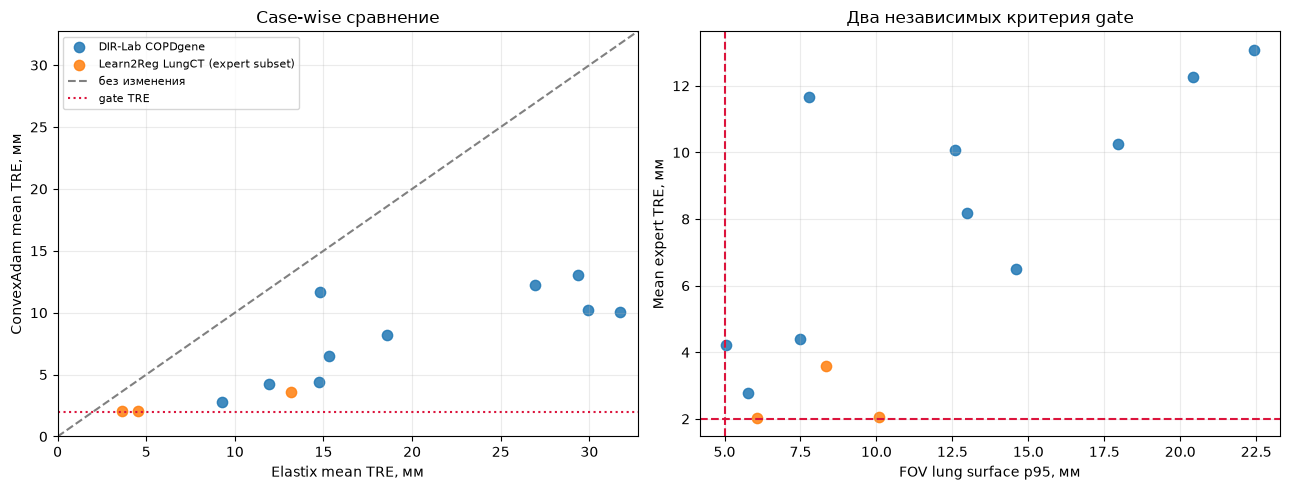

In [6]:
palette = {
    "DIR-Lab COPDgene": "#1f77b4",
    "Learn2Reg LungCT (expert subset)": "#ff7f0e",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

limit = (
    max(
        comparison["expert_tre_after_mean_mm_elastix"].max(),
        comparison["expert_tre_after_mean_mm_convexadam"].max(),
    )
    + 1
)
for cohort, group in comparison.groupby("cohort", sort=False):
    axes[0].scatter(
        group["expert_tre_after_mean_mm_elastix"],
        group["expert_tre_after_mean_mm_convexadam"],
        s=55,
        alpha=0.85,
        color=palette[cohort],
        label=cohort,
    )
axes[0].plot([0, limit], [0, limit], "--", color="gray", label="без изменения")
axes[0].axhline(2.0, color="crimson", linestyle=":", label="gate TRE")
axes[0].set(
    xlim=(0, limit),
    ylim=(0, limit),
    xlabel="Elastix mean TRE, мм",
    ylabel="ConvexAdam mean TRE, мм",
    title="Case-wise сравнение",
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

for cohort, group in comparison.groupby("cohort", sort=False):
    axes[1].scatter(
        group["lung_fov_surface_p95_after_mm"],
        group["expert_tre_after_mean_mm_convexadam"],
        s=55,
        alpha=0.85,
        color=palette[cohort],
        label=cohort,
    )
axes[1].axvline(5.0, color="crimson", linestyle="--")
axes[1].axhline(2.0, color="crimson", linestyle="--")
axes[1].set(
    xlabel="FOV lung surface p95, мм",
    ylabel="Mean expert TRE, мм",
    title="Два независимых критерия gate",
)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Какие именно gate-критерии не пройдены

Зелёная ячейка означает прохождение отдельного критерия, но субъект допускается к парным измерениям только если зелёные **все** ячейки его строки.


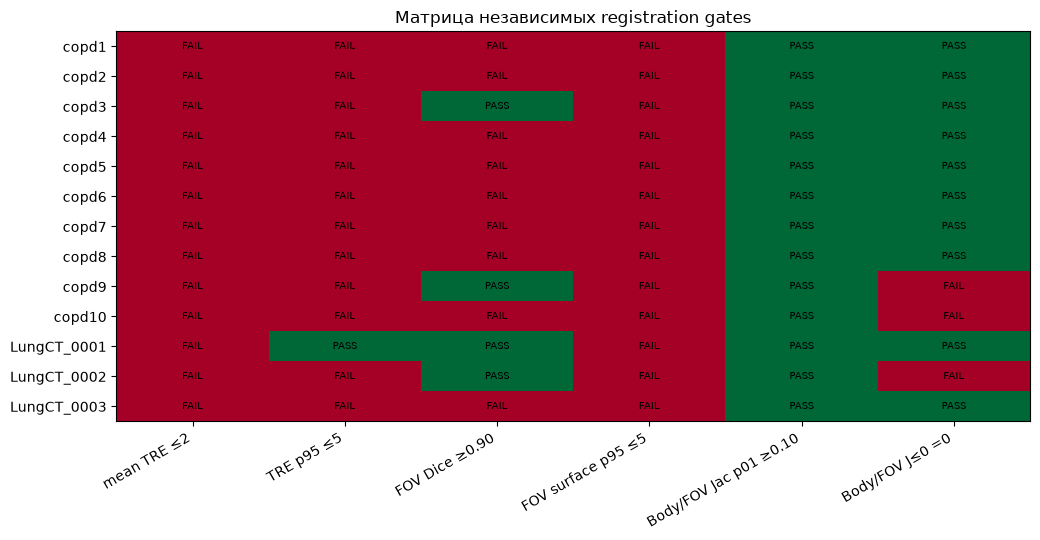

,Субъектов с FAIL
gate_reasons,
expert_tre_mean,13
lung_surface_p95_fov,13
expert_tre_p95,12
lung_dice_fov,9
folding_body_fov,3


In [7]:
criteria = pd.DataFrame(
    {
        "mean TRE ≤2": locked["expert_tre_after_mean_mm"].le(2.0),
        "TRE p95 ≤5": locked["expert_tre_after_p95_mm"].le(5.0),
        "FOV Dice ≥0.90": locked["lung_fov_dice_after"].ge(0.90),
        "FOV surface p95 ≤5": locked["lung_fov_surface_p95_after_mm"].le(5.0),
        "Body/FOV Jac p01 ≥0.10": locked["body_fov_jacobian_p01"].ge(0.10),
        "Body/FOV J≤0 =0": locked["body_fov_nonpositive_jacobian_fraction"].eq(0.0),
    }
)
criteria.index = locked["subject_id"]

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.imshow(criteria.to_numpy(dtype=int), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(criteria.shape[1]), criteria.columns, rotation=30, ha="right")
ax.set_yticks(range(criteria.shape[0]), criteria.index)
for row in range(criteria.shape[0]):
    for col in range(criteria.shape[1]):
        ax.text(
            col,
            row,
            "PASS" if criteria.iat[row, col] else "FAIL",
            ha="center",
            va="center",
            fontsize=7,
        )
ax.set_title("Матрица независимых registration gates")
plt.tight_layout()
plt.show()

reason_counts = (
    locked["gate_reasons"]
    .fillna("")
    .str.split(";")
    .explode()
    .loc[lambda values: values.ne("")]
    .value_counts()
    .sort_values(ascending=False)
)
display(reason_counts.rename("Субъектов с FAIL").to_frame())

## Региональная ошибка

Региональные значения — средние expert TRE в нижней, средней и верхней третях лёгких, после чего ниже показана медиана по субъектам. Это диагностика направления следующей разработки, а не отдельный способ пройти gate.


Выборка,DIR-Lab COPDgene,Learn2Reg LungCT (expert subset)
Регион,,
Нижняя треть,13.69,2.23
Средняя треть,8.40,2.15
Верхняя треть,2.46,1.48


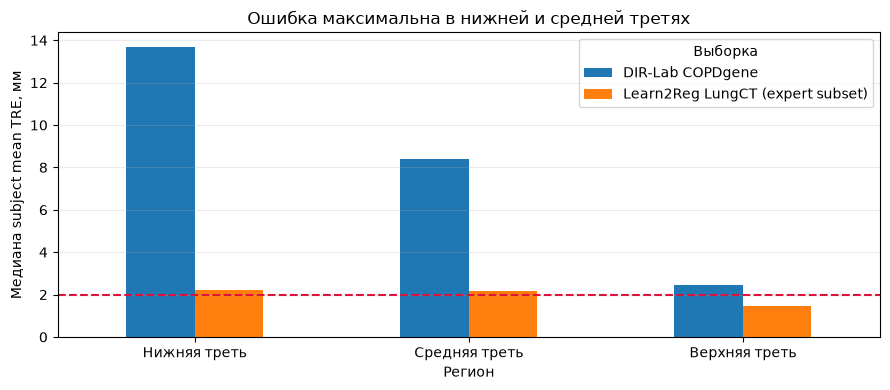

In [8]:
regional_columns = {
    "expert_inferior_tre_after_mean_mm": "Нижняя треть",
    "expert_middle_tre_after_mean_mm": "Средняя треть",
    "expert_superior_tre_after_mean_mm": "Верхняя треть",
}
regional_rows = []
for cohort, group in locked.groupby("cohort", sort=False):
    for column, region in regional_columns.items():
        regional_rows.append(
            {
                "Выборка": cohort,
                "Регион": region,
                "Медиана subject mean TRE, мм": group[column].median(),
            }
        )
regional = pd.DataFrame(regional_rows)
region_order = list(regional_columns.values())
display(
    regional.pivot(index="Регион", columns="Выборка", values="Медиана subject mean TRE, мм")
    .reindex(region_order)
    .round(2)
)

pivot = regional.pivot(
    index="Регион", columns="Выборка", values="Медиана subject mean TRE, мм"
).reindex(region_order)
ax = pivot.plot.bar(figsize=(9, 4), color=[palette[column] for column in pivot.columns])
ax.axhline(2.0, color="crimson", linestyle="--", label="gate mean TRE")
ax.set_ylabel("Медиана subject mean TRE, мм")
ax.set_title("Ошибка максимальна в нижней и средней третях")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Provenance

Хеши CSV относятся к полным subject-level batch-таблицам. Все 13 JSON должны ссылаться на одну locked-версию кода, один набор параметров и одну runtime-версию ConvexAdam/PyTorch.


In [9]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest().upper()


artifact_hashes = pd.DataFrame(
    [
        {"Артефакт": path.relative_to(ARTIFACT_ROOT).as_posix(), "SHA-256": sha256_file(path)}
        for path in [*development_paths.values(), *locked_paths.values()]
    ]
)
display(artifact_hashes)

provenance_rows = []
for folder in [
    locked_paths["DIR-Lab COPDgene"].parent,
    locked_paths["Learn2Reg LungCT (expert subset)"].parent,
]:
    for path in sorted(folder.glob("*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        provenance_rows.append(
            {
                "code_version": payload["provenance"]["code_version"],
                "manifest_sha256": payload["provenance"]["pair_manifest_sha256"],
                "parameters": json.dumps(payload["parameters"], sort_keys=True),
                "torch": payload["runtime"]["torch_version"],
                "convexadam": payload["runtime"]["convexadam_version"],
            }
        )
provenance = pd.DataFrame(provenance_rows)
print(f"JSON subject artifacts: {len(provenance)}")
print(f"Уникальных code versions: {provenance['code_version'].nunique()}")
print(f"Уникальных parameter sets: {provenance['parameters'].nunique()}")
display(provenance.drop(columns="parameters").drop_duplicates())

,Артефакт,SHA-256
0,results/registration/convexadam_development/de...,784FEBFCB071F87894E50722E7157BCA9756BFF3719597...
1,results/registration/convexadam_development/co...,4710E0BA0FB6363BE284EB81EC0B4B0C1552E31EC999FC...
2,results/registration/convexadam_development/se...,5CCC82D592C9D7B12B61E2CEF816DE569D792ADAE5EC93...
3,results/registration/convexadam_locked/dirlab/...,7B9F691B0BAD96B9634AF9949EB95F56CAA3C9F812ED7F...
4,results/registration/convexadam_locked/lungct/...,98784CAB90464A76D85279322C1F626852DA5CB3F182E9...


JSON subject artifacts: 13
Уникальных code versions: 1
Уникальных parameter sets: 1


,code_version,manifest_sha256,torch,convexadam
0,9cc725e9e809e1bccdd638f8c99ca762cbb44939,788f749c02dfab356ad8cb3d49414d9bf1bc0b60d23303...,2.5.1+cu118,0.2.0


In [10]:
passed = int(locked["gate_pass"].sum())
total = len(locked)
better = int(
    (
        comparison["expert_tre_after_mean_mm_convexadam"]
        < comparison["expert_tre_after_mean_mm_elastix"]
    ).sum()
)
fields = list((ARTIFACT_ROOT / "results/registration/convexadam_locked").glob("*/*.field.npz"))
baseline_median = comparison["expert_tre_after_mean_mm_elastix"].median()
convexadam_median = comparison["expert_tre_after_mean_mm_convexadam"].median()

verdict = (
    f"## Итог: registration gate пройден у {passed}/{total}\n\n"
    "ConvexAdam — существенно более сильный baseline: expert mean TRE улучшен "
    f"относительно Elastix в **{better}/{total}** случаях, общая медиана "
    f"снизилась с **{baseline_median:.2f} до {convexadam_median:.2f} мм**.\n\n"
    "Но это **не разрешает** строить парные карты изменения формы лёгких или "
    "толщины тканей: у всех субъектов нарушены mean-TRE и FOV-surface gates, "
    "полный gate не прошёл никто. Сохранённых разрешённых dense fields: "
    f"**{len(fields)}**.\n\n"
    "Следующий шаг — не подбор этой конфигурации по expert test, а новый "
    "заранее заданный кандидат с явной обработкой плеврального скольжения, "
    "диафрагмы и нижних отделов. До его независимого прохождения benchmark "
    "парные карты толщины остаются заблокированы.\n"
)
display(Markdown(verdict))

## Итог: registration gate пройден у 0/13

ConvexAdam — существенно более сильный baseline: expert mean TRE улучшен относительно Elastix в **13/13** случаях, общая медиана снизилась с **14.83 до 6.50 мм**.

Но это **не разрешает** строить парные карты изменения формы лёгких или толщины тканей: у всех субъектов нарушены mean-TRE и FOV-surface gates, полный gate не прошёл никто. Сохранённых разрешённых dense fields: **0**.

Следующий шаг — не подбор этой конфигурации по expert test, а новый заранее заданный кандидат с явной обработкой плеврального скольжения, диафрагмы и нижних отделов. До его независимого прохождения benchmark парные карты толщины остаются заблокированы.
